# UPRM Hackathon 2026 - Object Detection using Convolutional Neural Networks

**Author:** Hamzah Abdulrazzaq, Chelsea Cantone, Erika Hall, Edgar Perez

**Date:** September 25-27, 2026

**Objective:** UPRM Hackathon 2026 will be focused on exploring the capabilities of Convolutional Neural Networks (CNNs) in tackling complex object detection tasks. Specifically, participants will delve into the realm of single-class object detection using the 'Remondis Contamination Dataset' (RCD), which comprises truck-mounted waste camera imagery captured in real-world waste management operations. The dataset includes KITTI-format annotated images featuring plastic_bag instances of varying sizes, occlusion levels, lighting conditions, and background clutter, with bounding-box labels marking each target object. The task at hand is to design and optimize CNN-based detection architectures to accurately localize and classify plastic bags within a given image. The challenge lies in developing a robust model that can effectively handle the complexities of bounding-box regression combined with classification, requiring meticulous attention to data preprocessing, hyper-parameter tuning, and potentially incorporating techniques such as transfer learning, data augmentation, anchor tuning, and ensemble methods. The winning submissions will be evaluated based on their performance, with a key metric being the model's ability to achieve high mean Average Precision at IoU 0.50 (mAP@50) on the validation split, balancing precision and recall across detected instances.

## Table of Contents
1. [Background Information](#1-background-information)
    - [1.1. Convolutional Neural Networks](#11-convolutional-neural-networks)
    - [1.2. Object Detection vs Image Classification (Multi-label)](#12-object-detection-vs-image-classification-multi-label)
    - [1.3 An Example Use Case of Object Detection for Lockheed Martin](#13-an-example-use-case-of-object-detection-for-lockheed-martin)
    - [1.4 Key Terms](#14-key-terms)
    - [1.5 Helpful Resources](#15-helpful-resources)
2. [Setup](#2-setup)
    - [2.1. Download Data](#21-download-data)
    - [2.2 Importing Necessary Libraries](#22-importing-necessary-libraries)
    - [2.3 Custom Image Dataset](#23-custom-image-dataset)
    - [2.4 Image Augmentation](#24-image-augmentation)
3. [Training Loop](#3-training-loop)
    - [3.1 CNN Model Architecture](#31-cnn-model-architecture)
    - [3.2 Model Training](#32-model-training)
4. [Analysis](#4-analysis)
    - [4.1 Visualize Ground Truth vs Predictions](#41-visualize-ground-truth-vs-predictions)
    - [4.2 Performance Analysis (Where is the model underperforming)](#43-performance-analysis-where-is-the-model-underperforming)
5. [Test](#5-test)
    - [5.1 Download Test Data](#51-download-test-data)
    - [5.2 Create Test DataLoader](#51-create-test-dataloader)
    - [5.3 Grade Model on Test Set](#52-grade-model-on-test-set)
6. [Grading/Submission Guidelines](#6-gradingsubmission-guidelines)

## 1. Background Information

### 1.1 Convolutional Neural Networks:

A convolutional neural network (CNN or ConvNet) is a class of deep neural networks, most commonly applied to analyzing visual imagery. They have proven to be very effective in image and video recognition, recommender systems, image classification, medical image analysis, natural language processing, brain-computer interfaces, and financial time series modeling. CNNs are regularized versions of multilayer perceptrons. Multilayer perceptrons usually mean fully connected networks, that is, each neuron in one layer is connected to all neurons in the next layer. The "fully-connectedness" of these networks makes them prone to overfitting data. Typical ways of regularization include adding some form of magnitude measurement of weights to the loss function. CNNs take a different approach towards regularization: they take advantage of the hierarchical pattern in data and assemble more complex patterns using smaller and simpler patterns. Therefore, on the scale of connectedness and complexity, CNNs are on the lower extreme. Convolutional networks were inspired by biological processes in that the connectivity pattern between neurons resembles the organization of the animal visual cortex. Individual cortical neurons respond to stimuli only in a restricted region of the visual field known as the receptive field. The receptive fields of different neurons partially overlap such that they cover the entire visual field.

### 1.2 Object Detection vs Image Classification (Multi-label)

![choose_computer_vision_arch.png](./img/choose_computer_vision_arch.png)

*[Image Source](https://storage.ghost.io/c/2c/8d/2c8d8c0d-1c15-4b6d-825e-02b78d61d40a/content/images/size/w1000/size/w2000/2020/07/choose_computer_vision_arch.png)*

Object detection vs image classification are two related but different challenges in computer vision. Object detection looks at digital images and videos to locate objects of interest and label them.

| Image Classification (multi-label) | Object Detection |
| :--- | :--- |
| *Questions*: What labels are present in this image? | *Questions*: Is there an object here (objectness)? Where are the objects in the image (localization)? What labels are present (classification)? |
| *Output*: Class probabilities | *Output*: Bounding boxes, class probabilities, confidence scores (objectness) |
| *Evaluation metric*: F1-score | *Evaluation metric*: mAP@50 IoU, mean average precision at 50% Intersection over Union |

For explanation of mAP, see the references section below. mAP@50 indicates the mean Average Precision, where the Intersection over Union threshold is set to 0.5. Practically this means that the overlap of the ground truth bounding box to the predicted bounding box sufficiently overlap.

![Intersection over Union](./img/IoU-graphic.png)

[*Source*](https://miro.medium.com/v2/resize:fit:1400/format:webp/1*FrmKLxCtkokDC3Yr1wc70w.png)

### 1.3 An Example Use Case of Object Detection for Lockheed Martin
> GATR (Globally-scalable Automated Target Recognition) is a Lockheed Martin software system for real-time object detection and classification in satellite imagery on a worldwide basis. 
![GATR Object Detection](./img/Screenshot%202026-08-10%20134544.png)

[*Globally-scalable Automated Target Recognition (GATR) 2019*](https://arxiv.org/pdf/2009.04836)

### 1.4 Key Terms:
- **Anchor box** - in some object detection CNN models predefined reference boxes, of fixed size and aspect ratio, are used to localize objects
- **Backbone** - a backbone is a very unspecialized CNN that is inserted into a computer vision model to extract essential visual features from raw images (edges, corners, textures, shapes, etc.) into a feature map. Example backbone are ResNet, CSPNet, or a Vision Transformer.
- **Bounding box (bbox)** - the rectangular frame surrounding an object in an image or video. Our labeled dataset contains ground truth bounding boxes that were annotated by humans. We will compare the bounding boxes generated by our model to the ground truth annotations.
- **Localization** - uses regression to predict four numbers representing bounding box coordinates (center point, width, and height).
- **Objectness** - in computer vision, measure that scores how likely a specific image window contains an actual object rather than background.
- **Non-Maximum Suppression (NMS)** - A post processing technique to remove overlapping bounding boxes of the same objecct. Some computer vision models do not deal with this challenge.


### 1.5 Helpful Resources:

Neural Networks:
- [What are Convolutional Neural Networks](https://www.bing.com/videos/search?q=convolutional+neural+network&docid=603549927117705930&mid=E7ED04059A9474B24BFEE7ED04059A9474B24BFE&view=detail&FORM=VIRE)
- [CNN Explainer - Learn CNN In Your Browser](https://poloclub.github.io/cnn-explainer/)
- [Neural Network Playground](https://playground.tensorflow.org/)
- [Interactive Demo for Image kernels](https://deeplizard.com/resource/pavq7noze2)
- [Introduction to Pooling Layers](https://www.geeksforgeeks.org/deep-learning/cnn-introduction-to-pooling-layer/)

Object Detection
- [Overview of Object Detection](https://machinelearningmastery.com/object-recognition-with-deep-learning/)
- [Anchor-Based vs Anchor-Free Object Detection](https://www.abhik.ai/concepts/computer-vision/anchor-based-vs-anchor-free)
- [YOLO Object Detection Explained](https://www.datacamp.com/blog/yolo-object-detection-explained)
- [mAP (mean Average Precision) for Object Detection](https://jonathan-hui.medium.com/map-mean-average-precision-for-object-detection-45c121a31173)

## 2. Setup

### 2.1. Download Data

The data lives in the repository's `data/` folder, so the structure looks like:

```
data/
  training/
    image/      # *.jpg
    label/      # *.txt (KITTI format)
  val/
    image/      # *.jpg
    label/      # *.txt (KITTI format)
```

### 2.2 Importing Necessary Libraries

In [1]:
# Installs into the kernel running this notebook (a no-op when scripts/aws_setup.sh already set it up).
# requirements.txt is the organizers' file next to this notebook; the YOLO26 package is pinned explicitly.
import subprocess
import sys
from pathlib import Path

_reqs = ["-r", "requirements.txt"] if Path("requirements.txt").exists() else []
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *_reqs, "ultralytics==8.4.163"])

0

In [2]:
import math
import os
import random
from pathlib import Path
from typing import Callable, Dict, List, Optional, Tuple

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision.ops import boxes as box_ops
import torchvision.transforms.functional as TF
from PIL import Image

import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Repository root (assumes the notebook lives in <repo>/event_materials/).
REPO_ROOT = Path.cwd().parent if Path.cwd().name == "event_materials" else Path.cwd()

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Class id 0 is reserved for background in torchvision detection models.
CLASS_NAME_TO_ID = {"plastic_bag": 1}
NUM_CLASSES = 1 + len(CLASS_NAME_TO_ID)  # background + foreground

print(f"Using device: {DEVICE}")
print(f"NUM_CLASSES (background + foreground): {NUM_CLASSES}")
print(f"Repo root: {REPO_ROOT}")

if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))
else:
    print("No CUDA GPU detected.")


# ---------------------------------------------------------------------------
# Run configuration (corrected notebook: COCO-pretrained YOLO26s transfer learning)
#   "full"     - 150-epoch YOLO26s training from COCO-pretrained weights, scored on ALL val images.
#   "evaluate" - no training and no data conversion: load EVAL_CHECKPOINT and score it on ALL val images.
# ---------------------------------------------------------------------------
RUN_MODE = 'evaluate'
RUN_NAME = None                # None = "<mode>_yolo26s_640_<timestamp>"; use a NEW name for every full run
MODEL_WEIGHTS = "yolo26s.pt"   # COCO-pretrained starting point
EVAL_CHECKPOINT = 'C:\\Users\\diego\\OneDrive\\Documents\\GitHub\\Lockheed-Hackathon\\uprm-hackathon-2026\\weights\\yolo26n.pt'
RESUME_FROM = None             # continue an interrupted full run: path to its runs/detect/<run>/weights/last.pt

MODE_CFG = {
    "full": dict(epochs=150, batch=8, fraction=1.0, close_mosaic=15, save_period=5),
    "evaluate": dict(epochs=0, batch=8, fraction=1.0, close_mosaic=0, save_period=-1),
}
if RUN_MODE not in MODE_CFG:
    raise ValueError(f"RUN_MODE must be one of {sorted(MODE_CFG)}, got {RUN_MODE!r}")
if RUN_MODE == "evaluate":
    if EVAL_CHECKPOINT is None:
        raise ValueError("RUN_MODE = 'evaluate' needs EVAL_CHECKPOINT set to a trained .pt file")
    if not Path(EVAL_CHECKPOINT).is_file():
        raise FileNotFoundError(f"EVAL_CHECKPOINT not found: {EVAL_CHECKPOINT}")
CFG = dict(MODE_CFG[RUN_MODE])

IMGSZ = 640
# Scoring settings: low confidence so the metric sees the whole precision-recall curve
EVAL_KW = dict(imgsz=640, conf=0.001, iou=0.7, max_det=300, augment=False)
DEVICE_ARG = "0" if torch.cuda.is_available() else "cpu"   # Ultralytics device string

import time
if RUN_NAME is None:
    RUN_NAME = f"{RUN_MODE}_yolo26s_{IMGSZ}_{time.strftime('%Y%m%d_%H%M%S')}"
print(f"RUN_MODE = {RUN_MODE!r}   RUN_NAME = {RUN_NAME!r}")

Using device: cuda
NUM_CLASSES (background + foreground): 2
Repo root: C:\Users\diego\OneDrive\Documents\GitHub\Lockheed-Hackathon\uprm-hackathon-2026
NVIDIA GeForce RTX 3070 Laptop GPU
RUN_MODE = 'evaluate'   RUN_NAME = 'evaluate_yolo26s_640_20260926_020213'


In [3]:
if torch.cuda.is_available():
    # Returns bytes; convert to MB
    allocated = torch.cuda.memory_allocated(0) / 1024**2
    reserved = torch.cuda.memory_reserved(0) / 1024**2
    
    print(f"Allocated by PyTorch Tensors: {allocated:.2f} MB")
    print(f"Cached/Reserved by PyTorch:    {reserved:.2f} MB")
    
    # Or print a highly detailed diagnostic summary
    print(torch.cuda.memory_summary(device=0))

if RUN_MODE == "full" and not torch.cuda.is_available():
    raise RuntimeError("Training needs a CUDA GPU - use a GPU instance/kernel (e.g. ml.g5.xlarge).")

Allocated by PyTorch Tensors: 0.00 MB
Cached/Reserved by PyTorch:    0.00 MB
|===========================================================================|
|                  PyTorch CUDA memory summary, device ID 0                 |
|---------------------------------------------------------------------------|
|            CUDA OOMs: 0            |        cudaMalloc retries: 0         |
|===========================================================================|
|        Metric         | Cur Usage  | Peak Usage | Tot Alloc  | Tot Freed  |
|---------------------------------------------------------------------------|
| Allocated memory      |      0 B   |      0 B   |      0 B   |      0 B   |
|       from large pool |      0 B   |      0 B   |      0 B   |      0 B   |
|       from small pool |      0 B   |      0 B   |      0 B   |      0 B   |
|---------------------------------------------------------------------------|
| Active memory         |      0 B   |      0 B   |      0 B   | 

In [4]:
import warnings 
warnings.filterwarnings("ignore")

### 2.3 Custom Image Dataset

A PyTorch Custom Image Dataset is a class that inherits from PyTorch's Dataset class which provides a way to create a dataset that is tailored to your requirements and needs. It integrates efficiently with PyTorch's DataLoader, allowing us to load and process images in batches during model training and validation

#### What is it used for?
- Data Loading: Standardized way to load images and labels from disk.
- Data Preprocessing: Consistent application of transformations (resizing, augmentation, etc.) to images.
- Batch Creation: Mini-batch generation for training.
- Memory Efficiency: Load images only when needed rather than storing entire dataset in memory. 

Provided below is a custom image dataset that you may use for this challenge. You may add your own modifications by reading through [PyTorch's documentation](https://docs.pytorch.org/tutorials/beginner/basics/data_tutorial.html). 

In [5]:
# Directory names differ between the two splits (hard-coded on disk).
_SPLIT_DIRS = {
    "train": ("image", "label"),
    "val":   ("image",   "label"),
    "test": ("image", "label")
}


def _parse_kitti_label(label_path: Path) -> Tuple[List[List[float]], List[int]]:
    """Parse a single KITTI-format .txt file into boxes and labels.

    Returns (boxes_xyxy, labels). Boxes with non-positive width/height are dropped.
    Only foreground classes in CLASS_NAME_TO_ID are kept; others are silently ignored.
    """
    boxes: List[List[float]] = []
    labels: List[int] = []
    if not label_path.exists():
        return boxes, labels
    with open(label_path, "r") as f:
        for raw in f:
            parts = raw.strip().split()
            if len(parts) < 8:
                continue
            cls = parts[0]
            if cls not in CLASS_NAME_TO_ID:
                continue
            xmin, ymin, xmax, ymax = (float(parts[4]), float(parts[5]),
                                      float(parts[6]), float(parts[7]))
            if xmax <= xmin or ymax <= ymin:
                continue
            boxes.append([xmin, ymin, xmax, ymax])
            labels.append(CLASS_NAME_TO_ID[cls])
    return boxes, labels


class KittiPlasticBagDataset(Dataset):
    """PyTorch Dataset over KITTI-format plastic-bag data (self-contained version)."""

    def __init__(
        self,
        root,
        split: str = "train",
        transforms: Optional[Callable] = None,
    ) -> None:
        if split not in _SPLIT_DIRS:
            raise ValueError(f"split must be one of {list(_SPLIT_DIRS)}, got {split!r}")
        self.split = split
        self.transforms = transforms

        root = Path(root)
        # Accept either the repo `data/` folder or a specific split root.
        if (root / "training").is_dir() and (root / "val").is_dir():
            split_root = root / ("training" if split == "train" else split)
        else:
            split_root = root
        img_dir_name, lbl_dir_name = _SPLIT_DIRS[split]
        self.image_dir = split_root / img_dir_name
        self.label_dir = split_root / lbl_dir_name
        if not self.image_dir.is_dir():
            raise FileNotFoundError(f"Image dir not found: {self.image_dir}")
        if not self.label_dir.is_dir():
            raise FileNotFoundError(f"Label dir not found: {self.label_dir}")

        stems = sorted(p.stem for p in self.image_dir.glob("*.jpg"))
        self.ids: List[str] = [s for s in stems if (self.label_dir / f"{s}.txt").exists()]
        if not self.ids:
            raise RuntimeError(f"No paired image/label files found under {split_root}")

    def __len__(self) -> int:
        return len(self.ids)

    def __getitem__(self, idx: int):
        stem = self.ids[idx]
        img_path = self.image_dir / f"{stem}.jpg"
        lbl_path = self.label_dir / f"{stem}.txt"

        img = Image.open(img_path).convert("RGB")
        boxes, labels = _parse_kitti_label(lbl_path)

        if boxes:
            boxes_t = torch.as_tensor(boxes, dtype=torch.float32)
            labels_t = torch.as_tensor(labels, dtype=torch.int64)
        else:
            boxes_t = torch.zeros((0, 4), dtype=torch.float32)
            labels_t = torch.zeros((0,), dtype=torch.int64)

        target = {
            "boxes": boxes_t,
            "labels": labels_t,
            "image_id": torch.tensor([idx], dtype=torch.int64),
        }

        if self.transforms is not None:
            img, target = self.transforms(img, target)
        else:
            img = TF.to_tensor(img)

        return img, target


def detection_collate_fn(batch):
    """Detection targets are variable-length; keep them as a tuple of dicts."""
    images, targets = list(zip(*batch))
    return list(images), list(targets)


### 2.4 Image Augmentation

Image augmentation is an absolutely wonderful way to artificially expand your training dataset, which is especially valuable when working with limited data — a common constraint in real-world image tasks. By creating variations of existing images through transformations like rotations, flips, zooms, and crops, you essentially teach your CNN to recognize objects under different viewing conditions without collecting additional data.

More fundamentally, augmentation directly addresses overfitting by preventing the network from memorizing exact pixel patterns. When a CNN sees the same exact images repeatedly, it tends to learn specific pixel configurations rather than generalizable features. By presenting slightly different versions each time, you force the network to learn robust representations that capture the essence of objects rather than superficial details.

Augmentation also introduces invariance properties into your model. For classification tasks, whether an image is slightly rotated, zoomed, or shifted shouldn't change the label. By training with these variations, your CNN develops translation, rotation, and scale invariance—crucial properties for real-world deployment where objects rarely appear in perfectly consistent positions or orientations.

The CustomImageDataset created above is setup to handle image transforms. An example is provided below with horizontal flip and color jitter transforms applied. See documentation [here](https://docs.pytorch.org/vision/stable/transforms.html?highlight=compose)

In this corrected notebook YOLO26 applies its own on-the-fly augmentation during training (mosaic, horizontal flip 0.5, scale 0.5; no mixup, vertical flips or rotation), configured as `AUGMENT` in the cell below. The `TrainTransforms` example is kept for reference but is not used by YOLO training.

In [6]:
from torchvision.transforms import ColorJitter


class TrainTransforms:
    """Light on-the-fly augmentation for the training split.

    - Random horizontal flip (with box coord update).
    - Photometric color jitter (brightness/contrast/saturation/hue) applied
      to the PIL image before tensor conversion. Reduces train/val
      overconfidence gap without needing to re-map bounding boxes.
    - PIL -> float tensor in [0, 1], CHW.
    """

    def __init__(self, hflip_prob: float = 0.5) -> None:
        self.hflip_prob = float(hflip_prob)
        self.color_jitter = ColorJitter(
            brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05,
        )

    def __call__(self, img: Image.Image, target: dict) -> Tuple[torch.Tensor, dict]:
        if self.hflip_prob > 0 and random.random() < self.hflip_prob:
            w = img.width
            img = TF.hflip(img)
            if target["boxes"].numel() > 0:
                boxes = target["boxes"].clone()
                x1 = w - boxes[:, 2]
                x2 = w - boxes[:, 0]
                boxes[:, 0] = x1
                boxes[:, 2] = x2
                target["boxes"] = boxes

        # Photometric jitter operates purely on pixel intensities; boxes
        # are unchanged, so no target update is needed here.
        img = self.color_jitter(img)

        img_t = TF.to_tensor(img)
        return img_t, target


# Augmentation actually used by YOLO26 training (passed to Ultralytics in section 3.2)
AUGMENT = dict(mosaic=1.0, fliplr=0.5, scale=0.5, mixup=0.0, flipud=0.0, degrees=0.0)
print("YOLO augmentation:", AUGMENT)

YOLO augmentation: {'mosaic': 1.0, 'fliplr': 0.5, 'scale': 0.5, 'mixup': 0.0, 'flipud': 0.0, 'degrees': 0.0}


### 2.6 Datasets and DataLoader

In [7]:
DATA_ROOT = REPO_ROOT / "data"
print("Data root:", DATA_ROOT)

# The organizers' Dataset is used for scoring; YOLO trains from a converted copy of the training split (below).
val_ds   = KittiPlasticBagDataset(root=DATA_ROOT, split="val")
print(f"val   samples: {len(val_ds)}")

# Evaluation batch size (training batch size comes from RUN_MODE)
BATCH_SIZE = 8
# NUM_WORKERS = 0 is the safe choice on SageMaker (small shared memory)
NUM_WORKERS = 0

# Exactly the starter notebook's val_loader (drop_last=True) ...
val_loader = DataLoader(
    val_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, collate_fn=detection_collate_fn,
    drop_last=True
)
# ... and one that scores every validation image (used to select checkpoints)
val_loader_full = DataLoader(
    val_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, collate_fn=detection_collate_fn,
    drop_last=False
)

# --- KITTI -> YOLO label conversion (training modes only) ---
# Boxes are normalized by each image's own size (the data mixes 1280x720, 640x480 and 480x320).
CLASS_NAMES = ["plastic_bag"]
YOLO_DATA_ROOT = REPO_ROOT / "yolo_data"

"""Convert the organizers' KITTI splits into an Ultralytics YOLO dataset (yolo_data/)."""

import argparse
import shutil
from dataclasses import dataclass
from pathlib import Path
from typing import Optional

import yaml
from PIL import Image


EXIF_ORIENTATION = 0x0112


@dataclass
class ConvertStats:
    images: int = 0
    boxes: int = 0
    dropped: int = 0


def kitti_line_to_yolo(line: str, img_w: int, img_h: int) -> Optional[str]:
    """One KITTI row -> 'cls cx cy w h' normalized to [0, 1], or None if the row is unusable."""
    parts = line.strip().split()
    if len(parts) < 8 or parts[0] not in CLASS_NAMES:
        return None
    x1, y1, x2, y2 = (float(v) for v in parts[4:8])
    x1, y1 = max(0.0, x1), max(0.0, y1)
    x2, y2 = min(float(img_w), x2), min(float(img_h), y2)
    if x2 <= x1 or y2 <= y1:
        return None
    cls_id = CLASS_NAMES.index(parts[0])
    cx = (x1 + x2) / 2.0 / img_w
    cy = (y1 + y2) / 2.0 / img_h
    w = (x2 - x1) / img_w
    h = (y2 - y1) / img_h
    return f"{cls_id} {cx:.6f} {cy:.6f} {w:.6f} {h:.6f}"


def convert_split(src_split_dir: Path, dst_root: Path, split: str, clean: bool = True) -> ConvertStats:
    """Copy <src>/image/*.jpg and write YOLO labels into <dst>/images/<split>, <dst>/labels/<split>."""
    src_split_dir, dst_root = Path(src_split_dir), Path(dst_root)
    img_dst = dst_root / "images" / split
    lbl_dst = dst_root / "labels" / split
    for d in (img_dst, lbl_dst):
        if clean and d.exists():
            # empty the folder but keep it: Windows/OneDrive can refuse to remove the directory itself
            for child in d.iterdir():
                shutil.rmtree(child) if child.is_dir() else child.unlink()
        d.mkdir(parents=True, exist_ok=True)
    (dst_root / "labels" / f"{split}.cache").unlink(missing_ok=True)  # Ultralytics label cache

    stats = ConvertStats()
    for img_path in sorted((src_split_dir / "image").glob("*.jpg")):
        lbl_path = src_split_dir / "label" / f"{img_path.stem}.txt"
        if not lbl_path.exists():
            continue  # the organizers' dataset also skips unpaired images
        if (img_dst / img_path.name).exists():
            raise FileExistsError(f"{img_dst / img_path.name} already exists; refusing to overwrite")
        with Image.open(img_path) as im:
            orientation = im.getexif().get(EXIF_ORIENTATION)
            if orientation not in (None, 1):
                raise ValueError(f"{img_path} has EXIF orientation {orientation}; labels would misalign")
            img_w, img_h = im.size
        rows = []
        for line in lbl_path.read_text(encoding="utf-8").splitlines():
            if not line.strip():
                continue
            row = kitti_line_to_yolo(line, img_w, img_h)
            if row is None:
                stats.dropped += 1
            else:
                rows.append(row)
        shutil.copy2(img_path, img_dst / img_path.name)
        (lbl_dst / f"{img_path.stem}.txt").write_text("".join(r + "\n" for r in rows))
        stats.images += 1
        stats.boxes += len(rows)
    return stats


def write_dataset_yaml(dst_root: Path) -> Path:
    dst_root = Path(dst_root).resolve()
    cfg = {"path": str(dst_root), "train": "images/train", "val": "images/val",
           "names": {i: name for i, name in enumerate(CLASS_NAMES)}}
    out = dst_root / "data.yaml"
    out.write_text(yaml.safe_dump(cfg, sort_keys=False))
    return out


def build_yolo_dataset(data_root: Path = DATA_ROOT, dst_root: Path = YOLO_DATA_ROOT, train_on_val: bool = False) -> Path:
    """Build the whole YOLO dataset; train_on_val=True also copies val images into train (final retrain only)."""
    data_root, dst_root = Path(data_root), Path(dst_root)
    jobs = [("training", "train", True), ("val", "val", True)]
    if train_on_val:
        jobs.append(("val", "train", False))
    for src_name, split, clean in jobs:
        s = convert_split(data_root / src_name, dst_root, split, clean=clean)
        print(f"{src_name} -> {split}: {s.images} images, {s.boxes} boxes, {s.dropped} dropped")
    return write_dataset_yaml(dst_root)


def _paired_images(split_dir: Path) -> list:
    return sorted(p.name for p in (split_dir / "image").glob("*.jpg") if (split_dir / "label" / f"{p.stem}.txt").exists())


def dataset_is_current(data_root: Path = DATA_ROOT, dst_root: Path = YOLO_DATA_ROOT) -> bool:
    """True if dst_root already holds exactly the converted train/val images and labels of data_root."""
    data_root, dst_root = Path(data_root), Path(dst_root)
    for src_name, split in (("training", "train"), ("val", "val")):
        want = _paired_images(data_root / src_name)
        have = sorted(p.name for p in (dst_root / "images" / split).glob("*.jpg"))
        labels = sorted(p.stem for p in (dst_root / "labels" / split).glob("*.txt"))
        if not want or have != want or labels != [Path(n).stem for n in want]:
            return False
    return True


def ensure_yolo_dataset(data_root: Path = DATA_ROOT, dst_root: Path = YOLO_DATA_ROOT) -> Path:
    """Reuse an up-to-date conversion (only data.yaml is rewritten, with THIS machine's path); otherwise rebuild."""
    if dataset_is_current(data_root, dst_root):
        print(f"reusing converted dataset in {dst_root}")
        return write_dataset_yaml(dst_root)
    return build_yolo_dataset(data_root, dst_root)

if RUN_MODE == "evaluate":
    DATA_YAML = None
    print("evaluate mode: training-data conversion skipped")
else:
    DATA_YAML = ensure_yolo_dataset(DATA_ROOT, YOLO_DATA_ROOT)  # data.yaml always holds THIS machine's path

_gpu = torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU (no CUDA GPU)"
_model = str(EVAL_CHECKPOINT) if RUN_MODE == "evaluate" else MODEL_WEIGHTS
print("=" * 88)
print(f"mode: {RUN_MODE} | GPU: {_gpu} | model: {_model}")
print(f"epochs: {CFG['epochs']} | train batch: {CFG['batch']} | train fraction: {CFG['fraction']} | "
      f"evaluated val images: {len(val_ds)}")
print("=" * 88)

Data root: C:\Users\diego\OneDrive\Documents\GitHub\Lockheed-Hackathon\uprm-hackathon-2026\data
val   samples: 199
evaluate mode: training-data conversion skipped
mode: evaluate | GPU: NVIDIA GeForce RTX 3070 Laptop GPU | model: C:\Users\diego\OneDrive\Documents\GitHub\Lockheed-Hackathon\uprm-hackathon-2026\weights\yolo26n.pt
epochs: 0 | train batch: 8 | train fraction: 1.0 | evaluated val images: 199


## 3. Training Loop

### 3.1 CNN Model Architecture

There are two ways to approaching the model architecture phase of the problem. 

1. Building your own CNN architecture. An example is provided below where modifications can be made. 
2. Using pretrained models.

#### Building Your Own CNN Architecture

__Advantages:__

- Complete control over the architecture design. 
- Freedom to experiment with novel layer arrangements, activation functions, and skip connections.
- No constraints from pretrained weights or architectures that may not be optimal for your domain.
- Typically results in a smaller, more compute efficient model since you only include what you need.

__Disadvantages:__

- Requires a bit more expertise and understanding of Neural Network design
- More epochs are needed as learning must start from random initialization
- Needs much more data to achieve good performance (often prohibitively large amounts)
- Higher risk of overfitting, especially with limited data

#### Using Pretrained Models

__Advantages:__

- Leverage powerful feature extractors trained on massive datasets (like ImageNet with 1.2M images)
- Dramatically reduced training time and computational requirements (though more compute resources are needed to get started)
- Excellent performance even with limited domain-specific data
- Built-in robustness against common image variations and noise
- Access to state-of-the-art architectures (ResNet, EfficientNet, Vision Transformers) without designing them

__Disadvantages:__

- Less control over the underlying architecture
- May include unnecessary complexity for simpler tasks
- Domain shift can be problematic if your images differ significantly from pretraining data
- Fixed input requirements (resolution, channels) that may require preprocessing

**This corrected notebook uses option 2:** a COCO-pretrained Ultralytics **YOLO26s** CNN detector, fine-tuned on our data.

#### Object Detection CNN Model Building Blocks
Recall that we are only predicting a single class (plastic bags)
- CNN Backbone to extract feature map
- Detection Head to produce objectness score (detecting foreground vs background) and bounding box regression

**CNN Backbone**

YOLO26s uses a pretrained convolutional backbone and a feature-pyramid neck (about 9.5M parameters in total, COCO-pretrained). It produces feature maps at strides 8, 16 and 32, so both small and large plastic bags are covered. The cell below loads it: the pretrained weights in `full` mode, or `EVAL_CHECKPOINT` in `evaluate` mode.

In [8]:
from ultralytics import YOLO

if RUN_MODE == "evaluate":
    yolo = YOLO(str(EVAL_CHECKPOINT))
elif RESUME_FROM is not None:
    yolo = YOLO(str(RESUME_FROM))
else:
    _local = REPO_ROOT / "weights" / MODEL_WEIGHTS
    yolo = YOLO(str(_local) if _local.exists() else MODEL_WEIGHTS)  # downloads the COCO weights on first use

yolo.info()
print("classes in this checkpoint:", len(yolo.names), "(the head is re-initialized for plastic_bag when training)")

YOLO26n summary: 260 layers, 2,572,280 parameters, 0 gradients, 6.2 GFLOPs


classes in this checkpoint: 80 (the head is re-initialized for plastic_bag when training)


**Detection Head**

The YOLO26 head predicts boxes and a class score per location. Training uses `single_cls=True`, so the only class is `plastic_bag`.

- **Head choice:** YOLO26 can run an NMS-free end-to-end head. By default the installed Ultralytics uses the NMS head, and the cell below records which one actually runs.
- **Scoring settings:** `conf=0.001` (so the mAP sees the full precision-recall curve), `iou=0.7` NMS, and at most 300 detections per image.

In [9]:
"""Make an Ultralytics YOLO model look like the organizers' torchvision-style detector."""

from pathlib import Path
from typing import Any, Dict, List, Optional, Union

import numpy as np
import torch
import torch.nn as nn

NMS_CANDIDATES = ("nms", "end2end")


def resolve_nms_kwarg(cfg_keys=None) -> str:
    """The installed Ultralytics predict() argument that selects YOLO26's NMS head vs its NMS-free end-to-end head.

    Verified against the installed default config rather than guessed; fails loudly if neither name exists.
    """
    if cfg_keys is None:
        from ultralytics.cfg import DEFAULT_CFG_DICT
        cfg_keys = DEFAULT_CFG_DICT
    for key in NMS_CANDIDATES:
        if key in cfg_keys:
            return key
    raise RuntimeError(f"installed ultralytics exposes none of {NMS_CANDIDATES}; cannot select the YOLO26 head")


try:
    NMS_KWARG = resolve_nms_kwarg()
except ImportError:  # ultralytics not installed (pure unit-test environments)
    NMS_KWARG = "nms"


def tensor_to_bgr_uint8(img: torch.Tensor) -> np.ndarray:
    """[3,H,W] float RGB in [0,1] (TF.to_tensor output) -> [H,W,3] uint8 BGR (Ultralytics' numpy convention)."""
    arr = img.detach().to("cpu", torch.float32).clamp(0.0, 1.0).mul(255.0).round().to(torch.uint8)
    return np.ascontiguousarray(arr.permute(1, 2, 0).numpy()[:, :, ::-1])

**Full Detector (organizer-compatible adapter)**

`YoloTorchvisionAdapter` wraps YOLO so the organizers' unchanged `evaluate_map50` and `visualize_predictions` can use it.
- **Input:** a list of RGB float tensors `[3, H, W]` (the `KittiPlasticBagDataset` output). They are converted to what YOLO expects.
- **Output:** `[{"boxes", "scores", "labels"}]`. Boxes are `xyxy` in **original-image pixels** and labels are always `1` (plastic_bag).
- **Safe `.eval()`:** the YOLO object is deliberately not a registered submodule, so `.eval()` can never start YOLO training.

In [10]:
class YoloTorchvisionAdapter(nn.Module):
    """forward(List[Tensor[3,H,W]]) -> List[{"boxes","scores","labels"}] in original-image pixel coords.

    Drop-in for the starter notebook's `evaluate_map50(model, loader, device)` and `visualize_predictions(...)`.
    """

    def __init__(
        self,
        weights: Union[str, Path, Any],
        imgsz: int = 640,
        conf: float = 0.001,
        iou: float = 0.7,
        max_det: int = 300,
        augment: bool = False,
        nms: Optional[bool] = None,
        device: Optional[str] = None,
    ) -> None:
        super().__init__()
        if isinstance(weights, (str, Path)):
            from ultralytics import YOLO
            weights = YOLO(str(weights))
        # Deliberately NOT a registered submodule: ultralytics' Model.train() is the training
        # entrypoint, so nn.Module.eval() recursing into it would launch a training run.
        object.__setattr__(self, "_yolo", weights)
        self.predict_kwargs: Dict[str, Any] = dict(
            imgsz=imgsz, conf=conf, iou=iou, max_det=max_det, augment=augment, verbose=False)
        if nms is not None:
            self.predict_kwargs[NMS_KWARG] = nms
        if device is not None:
            self.predict_kwargs["device"] = device

    def train(self, mode: bool = True) -> "YoloTorchvisionAdapter":
        self.training = mode  # inference-only wrapper; never recurse into the YOLO object
        return self

    def inference_mode(self) -> Dict[str, Any]:
        """What actually ran: the NMS kwarg/value we passed and the head the loaded predictor ended up using."""
        predictor = getattr(self._yolo, "predictor", None)
        backend = getattr(predictor, "model", None)
        return {"nms_kwarg": NMS_KWARG, "nms_value": self.predict_kwargs.get(NMS_KWARG),
                "end2end_head": getattr(backend, "end2end", None),
                **{k: v for k, v in self.predict_kwargs.items() if k != "verbose"}}

    @torch.no_grad()
    def forward(self, images: List[torch.Tensor], targets: Optional[list] = None) -> List[Dict[str, torch.Tensor]]:
        if not images:
            return []
        results = self._yolo.predict([tensor_to_bgr_uint8(img) for img in images], **self.predict_kwargs)
        outputs = []
        for res in results:
            xyxy = res.boxes.xyxy.detach().cpu().float().reshape(-1, 4)
            scores = res.boxes.conf.detach().cpu().float().reshape(-1)
            outputs.append({"boxes": xyxy, "scores": scores,
                            "labels": torch.ones(scores.numel(), dtype=torch.int64)})
        return outputs


# Sanity check: .eval() can never reach YOLO.train()
_check = YoloTorchvisionAdapter(yolo, device=DEVICE_ARG, **EVAL_KW)
assert _check.eval() is _check and list(_check.children()) == []
print("adapter OK | NMS-mode argument in this Ultralytics:", NMS_KWARG)

adapter OK | NMS-mode argument in this Ultralytics: nms


### 3.2 Model Training

Ultralytics training from **COCO-pretrained** YOLO26s weights. Epochs, batch size and the training fraction come from `RUN_MODE`.

The fixed settings are:
- early stopping off (`patience=0`)
- cosine learning-rate schedule
- mixed precision
- `optimizer="auto"` (the resolved choice is recorded)
- seed 42
- mosaic turned off for the final epochs

The run configuration and environment are written to the run folder **before** training starts.

In [11]:
# Run configuration + environment metadata (written before training starts)
PROJECT_ROOT = REPO_ROOT
"""Capture the software/hardware environment of a run (written before training starts)."""

import json
import platform
import socket
import subprocess
import sys
from datetime import datetime
from pathlib import Path
from typing import Any, Dict



def code_version(root: Path = PROJECT_ROOT) -> Dict[str, Any]:
    """Git SHA (+dirty flag) when run from a checkout, else the packaged manifest's code-tree hash."""
    try:
        sha = subprocess.run(["git", "rev-parse", "HEAD"], cwd=root, capture_output=True, text=True,
                             timeout=10, check=True).stdout.strip()
        dirty = subprocess.run(["git", "status", "--porcelain"], cwd=root, capture_output=True, text=True,
                               timeout=10, check=True).stdout.strip() != ""
        return {"git_sha": sha, "git_dirty": dirty}
    except (OSError, subprocess.SubprocessError):
        pass
    for manifest in (root / "manifest.json", root.parent / "manifest.json"):
        if manifest.exists():
            return {"code_tree_sha256": json.loads(manifest.read_text(encoding="utf-8")).get("code_tree_sha256")}
    return {}


def environment() -> Dict[str, Any]:
    import torch
    info: Dict[str, Any] = {
        "time": datetime.now().isoformat(timespec="seconds"),
        "python": sys.version.split()[0],
        "platform": platform.platform(),
        "hostname": socket.gethostname(),
        "torch": torch.__version__,
        "cuda_runtime": torch.version.cuda,
        "cudnn": torch.backends.cudnn.version() if torch.backends.cudnn.is_available() else None,
        "cuda_available": torch.cuda.is_available(),
    }
    try:
        import torchvision
        info["torchvision"] = torchvision.__version__
    except ImportError:
        info["torchvision"] = None
    try:
        import ultralytics
        info["ultralytics"] = ultralytics.__version__
    except ImportError:
        info["ultralytics"] = None
    if torch.cuda.is_available():
        props = torch.cuda.get_device_properties(0)
        info["gpu"] = props.name
        info["gpu_mem_gb"] = round(props.total_memory / 1024 ** 3, 2)
    info.update(code_version())
    return info


def write_json(path: Path, data: Dict[str, Any]) -> Path:
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text(json.dumps(data, indent=2, default=str), encoding="utf-8")
    return path

RUNS_DIR = REPO_ROOT / "runs" / "detect"
TRAIN_ARGS = dict(
    data=str(DATA_YAML) if DATA_YAML is not None else None,
    project=str(RUNS_DIR), name=RUN_NAME, exist_ok=False,
    epochs=CFG["epochs"], imgsz=IMGSZ, batch=CFG["batch"], fraction=CFG["fraction"],
    patience=0, optimizer="auto", cos_lr=True, amp=torch.cuda.is_available(), seed=SEED, deterministic=True,
    close_mosaic=CFG["close_mosaic"], save_period=CFG["save_period"], cache=False, workers=NUM_WORKERS,
    single_cls=True, pretrained=True, device=0 if torch.cuda.is_available() else "cpu", plots=True, val=True,
    **AUGMENT,
)

RUN_DIR = None
if RUN_MODE == "evaluate":
    print("evaluate mode: no training run is configured")
elif RESUME_FROM is not None:
    RUN_DIR = Path(RESUME_FROM).resolve().parent.parent
    if (RUN_DIR / "rcd_done.json").exists():
        raise RuntimeError(f"{RUN_DIR} already completed - never resume/overwrite a finished run")
    RUN_NAME = RUN_DIR.name  # models/<RUN_NAME>/ matches the resumed run folder
    print("resuming", RUN_DIR)
else:
    RUN_DIR = RUNS_DIR / RUN_NAME
    if RUN_DIR.exists():
        raise FileExistsError(f"{RUN_DIR} already exists - choose a new RUN_NAME")
    write_json(RUN_DIR / "rcd_train_config.json", {"run_mode": RUN_MODE, "train_args": TRAIN_ARGS, "eval_kw": EVAL_KW})
    write_json(RUN_DIR / "rcd_env.json", environment())
    TRAIN_ARGS["exist_ok"] = True  # the folder now only holds our metadata
    print("run folder:", RUN_DIR)
print({k: TRAIN_ARGS[k] for k in ("epochs", "batch", "fraction", "imgsz", "close_mosaic", "save_period", "patience")})

evaluate mode: no training run is configured
{'epochs': 0, 'batch': 8, 'fraction': 1.0, 'imgsz': 640, 'close_mosaic': 0, 'save_period': -1, 'patience': 0}


In [12]:
# Calculate mAP@50 helper function
@torch.no_grad()
def evaluate_map50(model, loader, device) -> float:
    model.eval()
    all_scores: List[float] = []
    all_matches: List[int] = []  # 1 = TP, 0 = FP
    total_gt = 0
    
    # Look through each image and make a prediction
    # Compare each prediction to all ground truth boxes and
    # compute an IoU. If that IoU is >0.50 then consider it a match
    for images, targets in loader:
        images_d = [img.to(device) for img in images]
        preds = model(images_d)
        for pred, tgt in zip(preds, targets):
            gt_boxes = tgt["boxes"]
            total_gt += int(gt_boxes.shape[0])

            p_boxes = pred["boxes"].detach().cpu()
            p_scores = pred["scores"].detach().cpu()

            # Sort predictions by score descending.
            order = p_scores.argsort(descending=True)
            p_boxes = p_boxes[order]
            p_scores = p_scores[order]

            matched = torch.zeros(gt_boxes.shape[0], dtype=torch.bool)
            if gt_boxes.numel() == 0:
                for s in p_scores.tolist():
                    all_scores.append(s)
                    all_matches.append(0)
                continue

            if p_boxes.numel() == 0:
                continue
            
            # IoU calculation against all predicted boxes vs GT boxes
            # in current image
            iou = box_ops.box_iou(p_boxes, gt_boxes)  # [P, G]
            for pi in range(p_boxes.shape[0]):
                ious_p = iou[pi].clone()
                ious_p[matched] = -1.0
                best_iou, best_gt = ious_p.max(dim=0)
                if best_iou.item() >= 0.5:
                    matched[best_gt] = True
                    all_matches.append(1)
                else:
                    all_matches.append(0)
                all_scores.append(float(p_scores[pi].item()))

    if total_gt == 0 or not all_scores:
        return 0.0
    
    # Reorder matches from most to least confidence (high to low objectness)
    scores_t = torch.tensor(all_scores)
    matches_t = torch.tensor(all_matches, dtype=torch.float32)
    order = scores_t.argsort(descending=True)
    matches_t = matches_t[order]

    # Calculate average precision
    tp_cum = torch.cumsum(matches_t, dim=0) # cumulative true‑positives
    fp_cum = torch.cumsum(1 - matches_t, dim=0) # cumulative false‑positives
    recall = tp_cum / max(1, total_gt)
    precision = tp_cum / (tp_cum + fp_cum).clamp(min=1e-9)

    # 11-point interpolated AP (VOC-style).
    # The original PASCAL VOC challenge (2007‑2010) used exactly these 11 recall levels. 
    # The area under the interpolated precision‑recall curve is approximated by taking the 
    # average of the 11 sampled precisions, which yields the Average Precision (AP).
    ap = 0.0
    for t in torch.linspace(0, 1, 11):
        mask = recall >= t
        p = precision[mask].max().item() if mask.any() else 0.0
        ap += p / 11.0
    return float(ap)


In [13]:
# Helpers for the YOLO run (they replace the old CNN train_one_epoch loop)
import csv
import re
import shutil


def read_history(run_dir):
    """Per-epoch history recorded by Ultralytics (results.csv) as a list of dicts."""
    path = Path(run_dir) / "results.csv"
    if not path.exists():
        return []
    with open(path, newline="") as f:
        return [{k.strip(): float(v) for k, v in row.items()} for row in csv.DictReader(f)]


def run_checkpoints(run_dir):
    """Periodic epoch checkpoints, then the trainer's best.pt and last.pt."""
    w = Path(run_dir) / "weights"
    epochs = sorted(w.glob("epoch*.pt"), key=lambda p: int(re.sub(r"\D", "", p.stem)))
    return epochs + [p for p in (w / "best.pt", w / "last.pt") if p.exists()]

In [14]:
import time

# Run YOLO training (skipped in evaluate mode)
history = []
if RUN_MODE == "evaluate":
    print("evaluate mode: training skipped")
else:
    if torch.cuda.is_available():
        torch.cuda.reset_peak_memory_stats()
    total_start = time.time()
    if RESUME_FROM is not None:
        yolo.train(resume=True)
    else:
        yolo.train(**TRAIN_ARGS)
    total_elapsed = time.time() - total_start
    RUN_DIR = Path(yolo.trainer.save_dir)
    history = read_history(RUN_DIR)
    loss_keys = [k for k in history[0] if k.startswith("train/") and k.endswith("loss")]
    for h in history:
        print(f"epoch {int(h['epoch'])}: " + "  ".join(f"{k[6:]}={h[k]:.4f}" for k in loss_keys)
              + f"  Ultralytics val mAP50={h.get('metrics/mAP50(B)', float('nan')):.4f}")
    assert all(math.isfinite(h[k]) for h in history for k in loss_keys), "non-finite training loss"
    peak_gb = torch.cuda.max_memory_allocated() / 1024**3 if torch.cuda.is_available() else None
    opt = yolo.trainer.optimizer
    write_json(RUN_DIR / "rcd_done.json", {
        "optimizer_resolved": type(opt).__name__, "lr_initial": opt.param_groups[0].get("initial_lr"),
        "runtime_s": round(total_elapsed, 1), "peak_gpu_mem_gb": peak_gb, "epochs": len(history)})
    print(f"\nTotal training time: {total_elapsed:.2f}s ({total_elapsed/60:.2f} min)")
    print(f"optimizer: {type(opt).__name__}   peak GPU memory: {peak_gb:.2f} GB" if peak_gb else "")

evaluate mode: training skipped


In [15]:
### Save Model Checkpoint
# Score every saved checkpoint with the organizers' evaluate_map50 on the evaluated val images and keep the best.
if RUN_MODE == "evaluate":
    CKPT_PATH = Path(EVAL_CHECKPOINT)
else:
    ckpt_scores = []
    for ckpt in run_checkpoints(RUN_DIR):
        _a = YoloTorchvisionAdapter(str(ckpt), device=DEVICE_ARG, **EVAL_KW).eval()
        _full = evaluate_map50(_a, val_loader_full, DEVICE)
        ckpt_scores.append({"ckpt": ckpt, "full": _full, "mb": ckpt.stat().st_size / 1e6})
        print(f"{ckpt.name:<14} mAP@50 on {len(val_ds)} val images: {_full:.4f}")
    best = max(ckpt_scores, key=lambda s: (s["full"], -s["mb"]))  # exact ties -> smaller checkpoint
    with open(RUN_DIR / "org_scores.csv", "w", newline="") as f:
        csv.writer(f).writerows([("ckpt", "map50_full")] + [(s["ckpt"].name, repr(s["full"])) for s in ckpt_scores])

    SAVE_DIR = REPO_ROOT / "models" / RUN_NAME
    SAVE_DIR.mkdir(parents=True, exist_ok=True)
    CKPT_PATH = SAVE_DIR / "best.pt"
    shutil.copy2(best["ckpt"], CKPT_PATH)
    from ultralytics.utils.torch_utils import strip_optimizer
    strip_optimizer(str(CKPT_PATH))
    print(f"selected {best['ckpt'].name} -> saved to: {CKPT_PATH}")
    print(f'evaluate later without retraining: RUN_MODE = "evaluate", EVAL_CHECKPOINT = {str(CKPT_PATH)!r}')

# Reload from disk and score exactly what was saved
model = YoloTorchvisionAdapter(str(CKPT_PATH), device=DEVICE_ARG, **EVAL_KW).eval()
map50_full = evaluate_map50(model, val_loader_full, DEVICE)
map50 = evaluate_map50(model, val_loader, DEVICE)
print(f"validation mAP@50 (plastic_bag), all {len(val_ds)} evaluated val images: {map50_full:.4f}  ({map50_full!r})")
print(f"validation mAP@50 (plastic_bag), starter-notebook loader (drop_last=True): {map50:.4f}  ({map50!r})")
print("inference settings:", model.inference_mode())

validation mAP@50 (plastic_bag), all 199 evaluated val images: 0.1079  (0.10785218649967149)
validation mAP@50 (plastic_bag), starter-notebook loader (drop_last=True): 0.1087  (0.10872369615191763)
inference settings: {'nms_kwarg': 'nms', 'nms_value': None, 'end2end_head': False, 'imgsz': 640, 'conf': 0.001, 'iou': 0.7, 'max_det': 300, 'augment': False, 'device': '0'}


## 4. Analysis

### 4.1 Visualize Training Loss vs Epoch


In [16]:
# Plot training loss vs epochs (from the history Ultralytics recorded in results.csv)
if not history and RUN_MODE == "evaluate":
    history = read_history(Path(EVAL_CHECKPOINT).resolve().parent.parent)

if history:
    epochs_x = [h["epoch"] for h in history]
    fig, (ax, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    for key in [k for k in history[0] if k.endswith("loss")]:
        ax.plot(epochs_x, [h[key] for h in history], marker="o", label=key)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.set_title(f"Training/validation loss vs. epoch")
    ax.grid(True, alpha=0.3)
    ax.legend()

    # mAP@50 for validation vs Epoch (Ultralytics' own metric; the organizers' 11-point metric is in 3.2 / 4.2)
    ax2.plot(epochs_x, [h.get("metrics/mAP50(B)", float("nan")) for h in history], marker="o", label="val mAP50 (Ultralytics)")
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("mAP50")
    ax2.set_title(f"Validation mAP50 vs. epoch")
    ax2.grid(True, alpha=0.3)
    ax2.legend()
    plt.tight_layout()
    plt.show()
else:
    print("No training history available (evaluate mode without the checkpoint's results.csv).")

No training history available (evaluate mode without the checkpoint's results.csv).


### 4.2 Performance Analysis (Where is the model underperforming)

In [17]:
# --- Diagnostic: where is the model underperforming? ---
# Checks the predictions are well formed, shows the score distribution, and counts missed bags (false negatives)
# and false positives at a readable confidence threshold. Scoring above always uses conf=0.001.
@torch.no_grad()
def diagnose_model(model, loader, device, conf: float = 0.3, iou_match: float = 0.5):
    model.eval()
    n_above = {0.001: 0, 0.01: 0, 0.05: 0, 0.1: 0, 0.3: 0, 0.5: 0}
    n_pred = n_img = n_gt = tp = fp = fn = 0
    max_score = 0.0
    for images, targets in loader:
        preds = model([img.to(device) for img in images])
        for img, pred, tgt in zip(images, preds, targets):
            boxes, scores, labels = pred["boxes"], pred["scores"], pred["labels"]
            assert boxes.ndim == 2 and boxes.shape[1] == 4 and scores.shape == (boxes.shape[0],)
            assert torch.isfinite(boxes).all() and torch.isfinite(scores).all() and bool((labels == 1).all())
            h, w = img.shape[-2:]
            assert boxes.numel() == 0 or (boxes[:, 2].max() <= w + 1 and boxes[:, 3].max() <= h + 1)
            n_img += 1
            n_pred += int(scores.numel())
            if scores.numel():
                max_score = max(max_score, float(scores.max()))
            for thr in n_above:
                n_above[thr] += int((scores > thr).sum())
            kept = boxes[scores >= conf]
            gt = tgt["boxes"]
            n_gt += int(gt.shape[0])
            if gt.shape[0] and kept.shape[0]:
                iou = box_ops.box_iou(kept, gt)
                found = int((iou.max(dim=0).values >= iou_match).sum())
                good = int((iou.max(dim=1).values >= iou_match).sum())
            else:
                found = good = 0
            tp += found
            fn += int(gt.shape[0]) - found
            fp += int(kept.shape[0]) - good

    print(f"{n_img} val images, {n_gt} ground-truth bags, {n_pred} predictions (conf >= 0.001)")
    print(f"  max score seen: {max_score:.4f}")
    print("  predictions above each score threshold:")
    for thr, n in n_above.items():
        print(f"    > {thr:<6}: {n:>7d}")
    print(f"  at conf >= {conf}: bags found {tp}/{n_gt}, missed bags {fn}, false positives {fp}")

diagnose_model(model, val_loader_full, DEVICE)

199 val images, 537 ground-truth bags, 28495 predictions (conf >= 0.001)
  max score seen: 0.7650
  predictions above each score threshold:
    > 0.001 :   28495
    > 0.01  :    5588
    > 0.05  :     979
    > 0.1   :     403
    > 0.3   :      47
    > 0.5   :      12
  at conf >= 0.3: bags found 9/537, missed bags 528, false positives 38


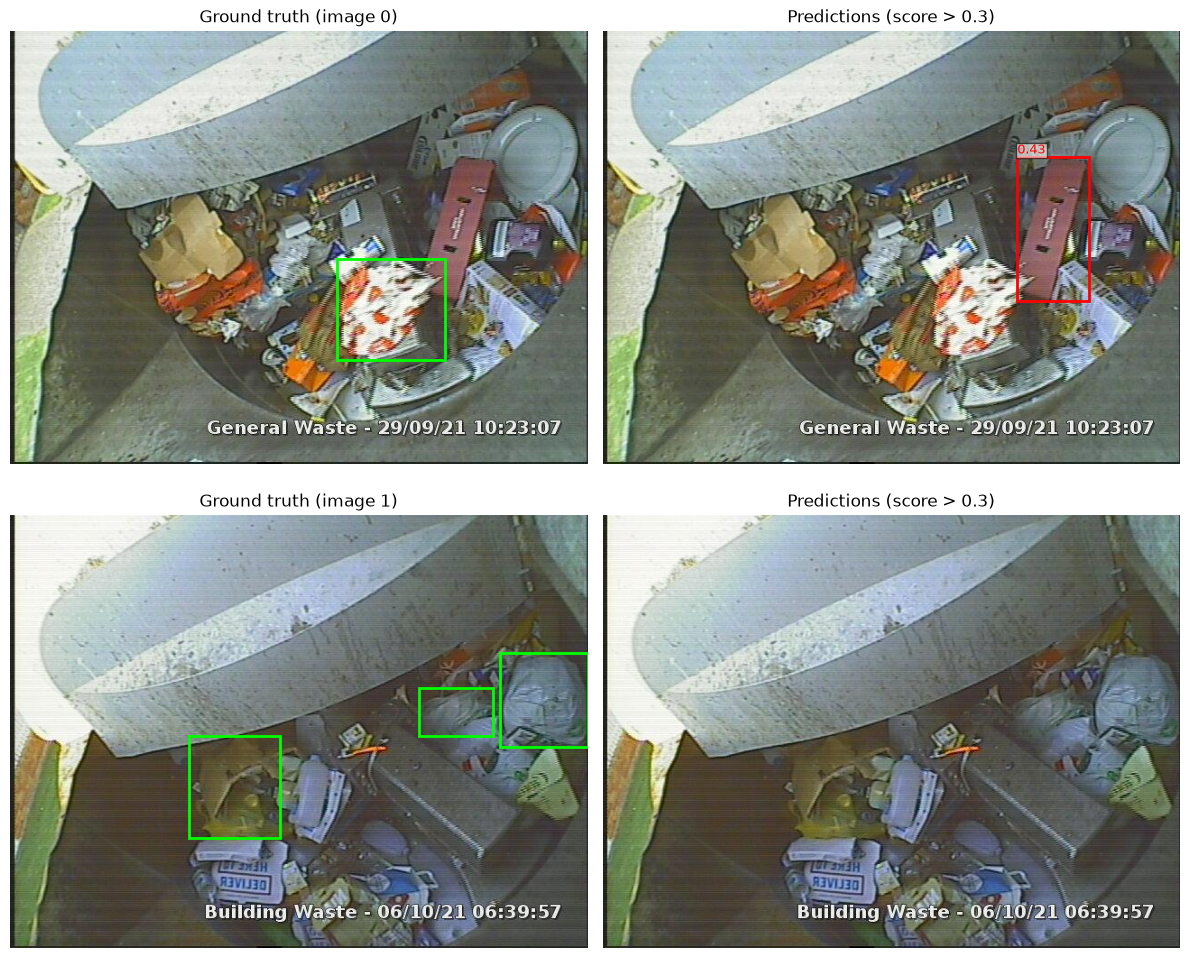

In [18]:
@torch.no_grad()
def visualize_predictions(model, dataset, device, num_images: int = 4, score_thresh: float = 0.3):
    model.eval()
    idxs = list(range(min(num_images, len(dataset))))
    fig, axes = plt.subplots(len(idxs), 2, figsize=(12, 5 * len(idxs)))
    if len(idxs) == 1:
        axes = axes[None, :]

    for row, idx in enumerate(idxs):
        img, target = dataset[idx]
        img_np = img.permute(1, 2, 0).cpu().numpy()

        # Ground truth
        ax_gt = axes[row, 0]
        ax_gt.imshow(img_np)
        ax_gt.set_title(f"Ground truth (image {idx})")
        ax_gt.axis("off")
        for box in target["boxes"]:
            x1, y1, x2, y2 = box.tolist()
            ax_gt.add_patch(patches.Rectangle(
                (x1, y1), x2 - x1, y2 - y1,
                fill=False, edgecolor="lime", linewidth=2,
            ))

        # Predictions
        preds = model([img.to(device)])[0]
        ax_pr = axes[row, 1]
        ax_pr.imshow(img_np)
        ax_pr.set_title(f"Predictions (score > {score_thresh})")
        ax_pr.axis("off")
        for box, score in zip(preds["boxes"].cpu(), preds["scores"].cpu()):
            if float(score) < score_thresh:
                continue
            x1, y1, x2, y2 = box.tolist()
            ax_pr.add_patch(patches.Rectangle(
                (x1, y1), x2 - x1, y2 - y1,
                fill=False, edgecolor="red", linewidth=2,
            ))
            ax_pr.text(x1, max(0, y1 - 4), f"{float(score):.2f}",
                       color="red", fontsize=9,
                       bbox=dict(facecolor="white", alpha=0.6, pad=1))

    plt.tight_layout()
    plt.show()


# Visualization hides boxes below 0.3 confidence; scoring above still uses conf=0.001
visualize_predictions(model, val_ds, DEVICE, num_images=2, score_thresh=0.3)

## 5. Test

Speak to a Hackathon Organizer when your team is ready to submit a final model. You will receive two keys to be entered below to download the test dataset and score your model.

In this notebook, set `RUN_OFFICIAL_TEST = True` in 5.1 only once the model and settings are frozen. The two keys are then asked for at runtime (password prompts), so they are never stored in the notebook. With the default `False`, Run All never prompts, downloads, or scores the official test set.

### 5.1 Download Test Data

In [19]:
# Official test access (organizer keys are typed at runtime prompts in the next cell, never stored here)
RUN_OFFICIAL_TEST = False

BUCKET = "uprm-hackathon-data"
PREFIX = "2026/test/"            # trailing slash is optional but recommended
DESTINATION = f"{REPO_ROOT}/data/test/"        # local root folder where files will be saved
REGION = "us-east-1"

In [20]:
import os
from pathlib import Path

if RUN_OFFICIAL_TEST:
    from getpass import getpass

    import boto3

    # Download
    s3 = boto3.resource('s3',
                        aws_access_key_id=getpass("AWS_ACCESS_KEY_ID: "),
                        aws_secret_access_key=getpass("AWS_SECRET_ACCESS_KEY: "),
                        region_name=REGION)

    bucket = s3.Bucket(BUCKET)

    for obj in bucket.objects.filter(Prefix=PREFIX):
        if obj.key.endswith('/'):  # skip "folder" placeholders
            continue
        rel_path = os.path.relpath(obj.key, PREFIX)
        local_path = Path(DESTINATION) / rel_path
        local_path.parent.mkdir(parents=True, exist_ok=True)
        print(f'Downloading {obj.key} -> {local_path}')
        bucket.download_file(obj.key, str(local_path))
    del s3, bucket
else:
    print("RUN_OFFICIAL_TEST is False - official test data not downloaded.")

RUN_OFFICIAL_TEST is False - official test data not downloaded.


### 5.2 Create Test DataLoader

In [21]:
# Create DataLoader for Test Set
test_loader = None
if RUN_OFFICIAL_TEST:
    test_ds   = KittiPlasticBagDataset(root=DATA_ROOT, split="test")
    print(f"test samples: {len(test_ds)}")
    test_loader = DataLoader(
        test_ds, batch_size=BATCH_SIZE, shuffle=False,
        num_workers=NUM_WORKERS, collate_fn=detection_collate_fn,
        drop_last=False
    )
else:
    print("RUN_OFFICIAL_TEST is False - no test loader.")

RUN_OFFICIAL_TEST is False - no test loader.


### 5.3 Grade Model on Test Set

In [22]:
if RUN_OFFICIAL_TEST and test_loader is not None:
    map50 = evaluate_map50(model, test_loader, DEVICE)
    print(f"Test mAP@50 (plastic_bag): {map50:.4f}")
    print(f"Test mAP@50 (plastic_bag), all digits: {map50!r}")
else:
    print("RUN_OFFICIAL_TEST is False - official test set not scored.")

RUN_OFFICIAL_TEST is False - official test set not scored.


# 6. Grading/Submission Guidelines

## Submissions
Please email your submissions to hamzah.abdulrazzaq@lmco.com. All these items must be complete in order for your submission to be considered for evaluation. 
> 1. Email title set to *yourteamname_submission* 
> 2. The python notebook with all your code (.ipynb) 
> 3. Your model checkpoint (.pt) file
> 4. mAP@50 test score copied in with all the digits

**NOTE**: If your email submission is blocked, please try resending the email with a .allow extension added to the file or email title.

## Evaluation Process
> - The submission deadline is on Sunday (9/27) 12PM.
> - Presentations will take place on Sunday (9/27) 2PM for the top 3 teams highest performing solutions. Teams will provide a walkthrough of their code. A winner shall be announced thereafter.